Figure saved to: C:\Users\tomos\OneDrive - Ulster University\GlacialExtractionData\scripts\figure_scripts\Figure7\Figure7.png


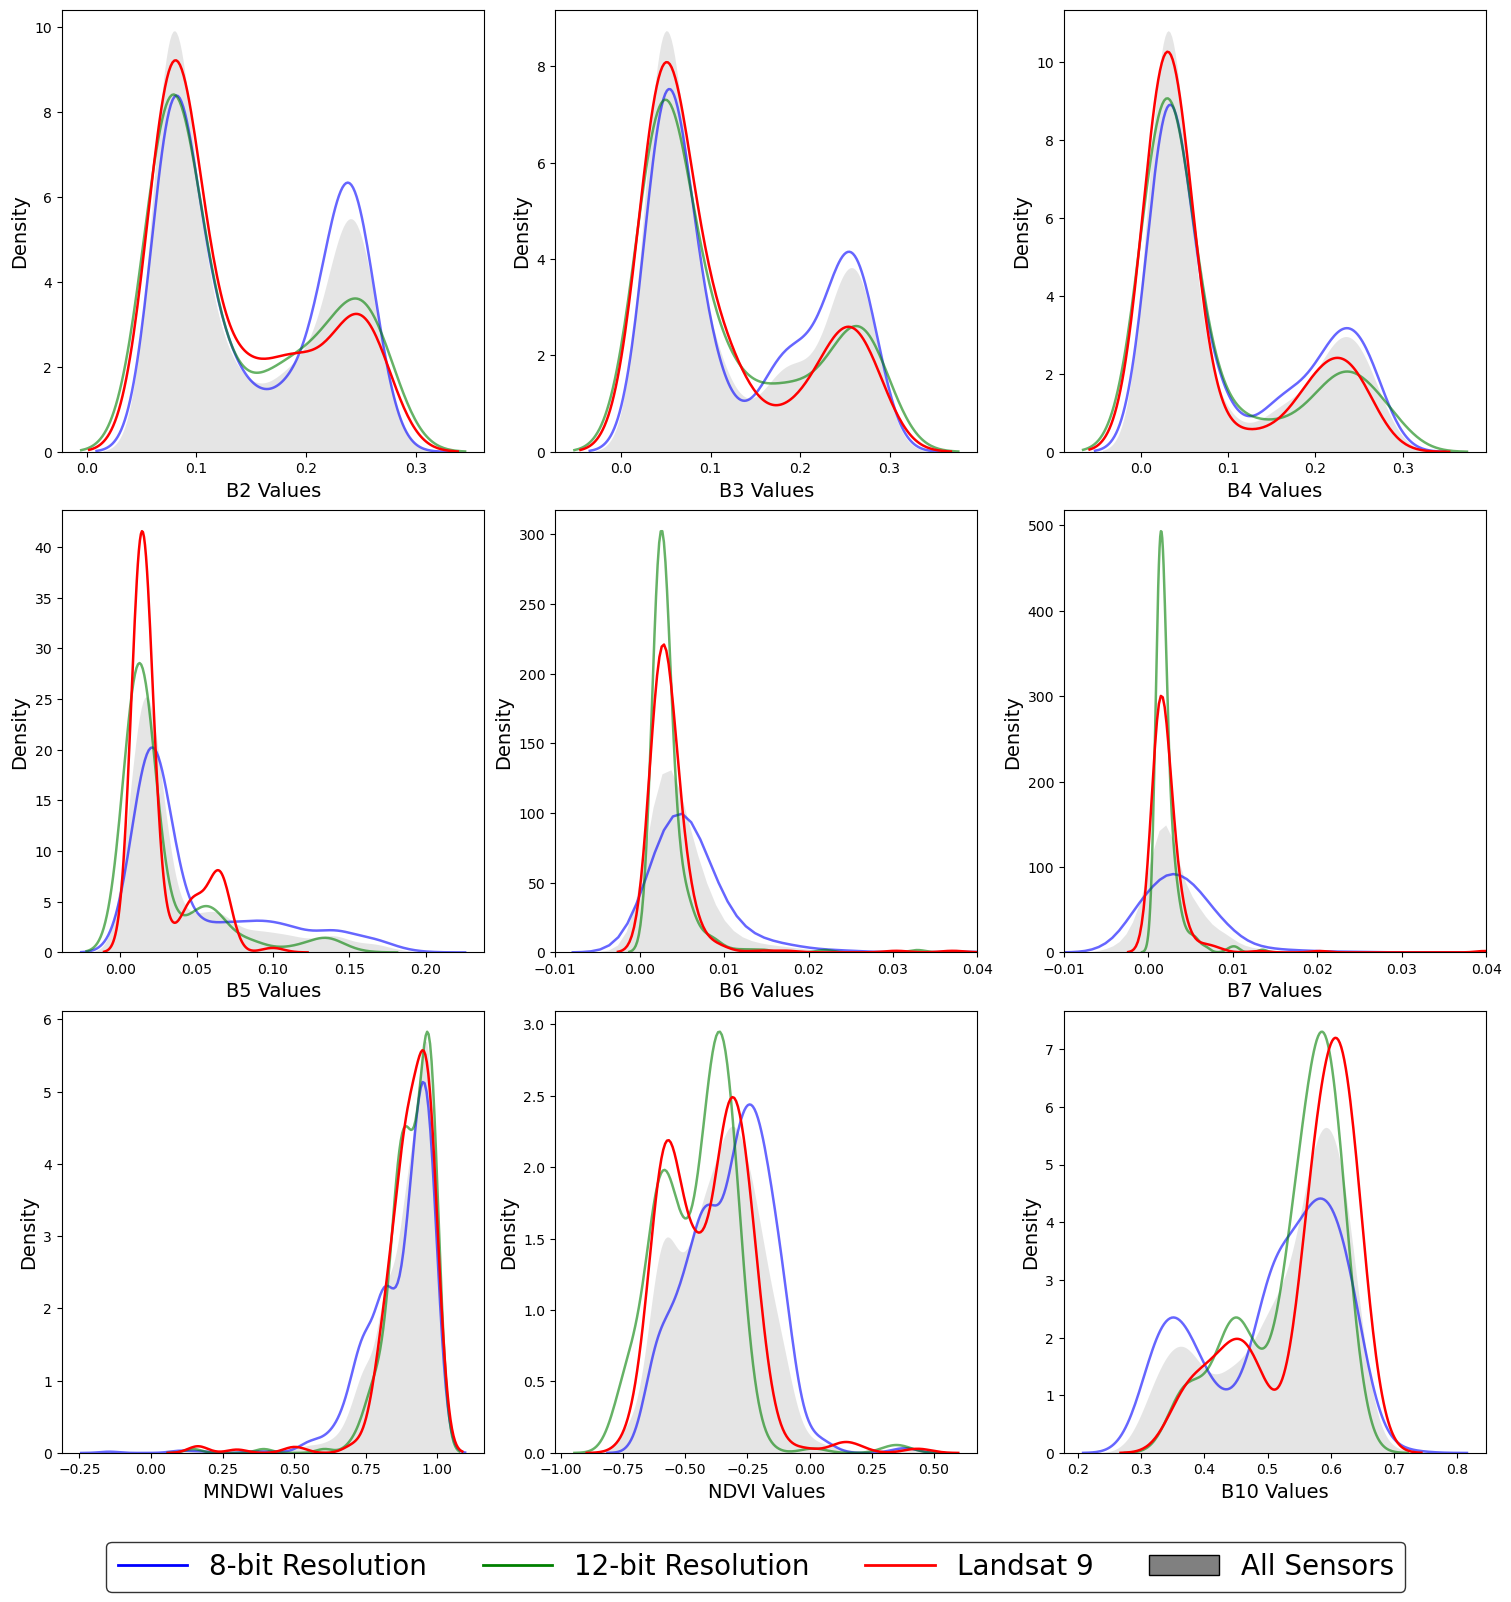

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import os

base_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()

file_path = os.path.join(base_dir, "KDE_distributions.csv")
plot_save_path = os.path.join(base_dir, "Figure7.png")

df = pd.read_csv(file_path)
df = df[df['Class'] == 'Water']

bands = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'MNDWI', 'NDVI', 'B10_normalized']
bands_to_plot = [band for band in bands if band in df.columns]

sensor_groups = {
    "8-bit Resolution": ["LT04", "LT05", "LE07"],
    "12-bit Resolution": ["LC08"],
    "Landsat 9": ["LC09"]
}

sensor_styles = {
    "8-bit Resolution": {"color": "blue", "linestyle": "-", "alpha": 0.6, "linewidth": 1.8},
    "12-bit Resolution": {"color": "green", "linestyle": "-", "alpha": 0.6, "linewidth": 1.8},
    "Landsat 9": {"color": "red", "linestyle": "-", "alpha": 1.0, "linewidth": 1.8},
    "All Sensors": {"color": "gray", "alpha": 0.2}
}

fig, axes = plt.subplots(3, 3, figsize=(15, 15), constrained_layout=True)
axes = axes.flatten()

for idx, band in enumerate(bands_to_plot):
    ax = axes[idx]

    # Plot each sensor group
    for group_label, sensor_list in sensor_groups.items():
        group_data = df[df['Sensor'].isin(sensor_list)]

        if not group_data.empty and band in group_data.columns:
            sns.kdeplot(
                data=group_data,
                x=band,
                color=sensor_styles[group_label]["color"],
                linestyle=sensor_styles[group_label]["linestyle"],
                linewidth=sensor_styles[group_label]["linewidth"],
                alpha=sensor_styles[group_label]["alpha"],
                ax=ax
            )

    sns.kdeplot(
        data=df,
        x=band,
        fill=True,
        color=sensor_styles["All Sensors"]["color"],
        alpha=sensor_styles["All Sensors"]["alpha"],
        linewidth=0,
        ax=ax
    )

    if band in ['B6', 'B7']:
        ax.set_xlim(-0.01, 0.04)

    label_band = "B10" if band == "B10_normalized" else band
    ax.set_xlabel(f"{label_band} Values", fontsize=14)
    ax.set_ylabel("Density", fontsize=14)

for idx in range(len(bands_to_plot), len(axes)):
    fig.delaxes(axes[idx])

handles = [
    Line2D([0], [0], color="blue", lw=2, label="8-bit Resolution"),
    Line2D([0], [0], color="green", lw=2, label="12-bit Resolution"),
    Line2D([0], [0], color="red", lw=2, label="Landsat 9"),
    Patch(facecolor="gray", edgecolor='black', label="All Sensors")
]

fig.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.015),
    ncol=4,
    fontsize=20,
    handlelength=2.5,
    frameon=True,
    edgecolor="black",
    facecolor="white"
)

plt.rcParams.update({'font.size': 14})

fig.savefig(plot_save_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {plot_save_path}")

plt.show()
plt.close(fig)